# Setup


📝 *Import required libraries and files:*

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


In [16]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

## 4.2.1. - Unseeded topic modelling

### 4.2.1.1. - Prepare df for model training

In [17]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    652440.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

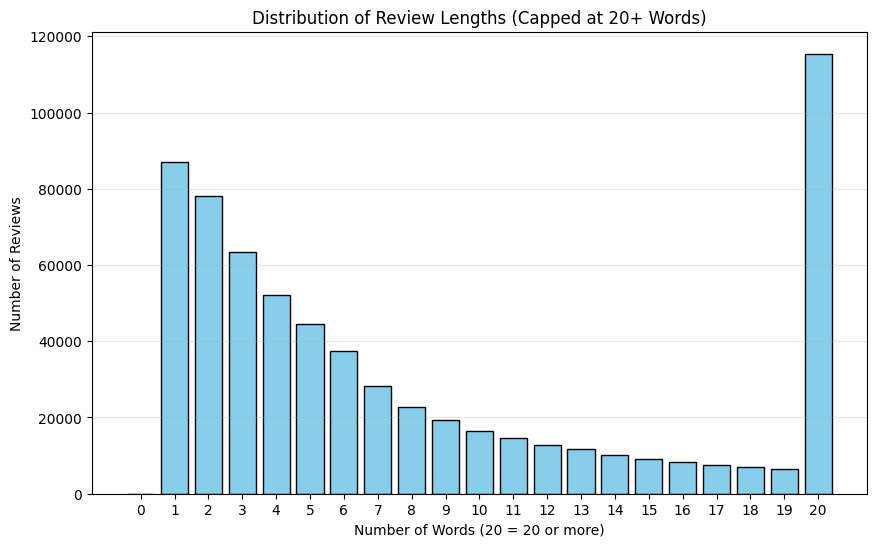

In [18]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [19]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 4]
df = df[df['review_date'] > pd.Timestamp('2021-10-01')]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (652440, 22)
Dataframe shape after filtering short reviews: (232026, 22)


In [20]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    df[col] = df[col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces
    
    for w in STOP_WORDS:
        df[col] = df[col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    return df

In [21]:
# Perform cleaning
df = bertopic_cleaning(df, col="review_text")

In [22]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 2]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (232026, 22)
Dataframe shape after filtering short reviews: (232019, 22)


### 4.2.1.2. - Define and train the model + Evaluate results

In [23]:
# get a random sample of reviews to speed up initial training
df = df.copy()
reviews = df["review_text"].to_list()

In [24]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(reviews, show_progress_bar=True)

Batches:   0%|          | 0/7251 [00:00<?, ?it/s]

In [25]:
# Vectorizer for English short texts
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=5,                 # ignores terms appearing in less than 5 documents
    max_df=0.7                # ignores terms appearing in more than 70% of documents
)

# Dimensionality reduction & clustering tuned for short reviews
umap_model = UMAP(
    n_neighbors=20,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tens to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility


hdbscan_model = HDBSCAN(
    min_cluster_size=75,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.5,    # Merge clusters within 0.4 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Create the BERTopic model
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    min_topic_size=250,
    verbose=True)

In [26]:
topics, probs = topic_model.fit_transform(reviews, embeddings)

2025-10-20 17:46:50,881 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-20 17:55:32,146 - BERTopic - Dimensionality - Completed ✓
2025-10-20 17:55:32,163 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-20 18:22:02,487 - BERTopic - Cluster - Completed ✓
2025-10-20 18:22:02,570 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-20 18:22:09,371 - BERTopic - Representation - Completed ✓


In [27]:
# Save Bertopic model 
topic_model.save("../assets/models/bertopic_model")

2025-10-20 18:22:10,240 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.1.3. - Model evaluation and finetune

In [28]:
topic_model = BERTopic.load("../assets/models/bertopic_model")

In [29]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4050,-1_app easy_use easy_use great_use very,"[app easy, use easy, use great, use very, easy...","[Great app,easy to use., Great app, easy to us..."
1,0,149174,0_the_app_my_is,"[the, app, my, is, of, in, this, you, the app,...",[So far it has been a very buggy journey with ...
2,1,46032,1_good_so_quick_use and,"[good, so, quick, use and, works, very easy, s...","[So easy and quick., So far so good!, So far s..."
3,2,6916,2_secure_reliable_safe_and secure,"[secure, reliable, safe, and secure, and relia...","[Very good, secure & reliable., So safe and se..."
4,3,6401,3_service_good service_customer_great service,"[service, good service, customer, great servic...","[It's a service., service 👏 👍 👌, 5 service !]"
5,4,2859,4_cheque_paying in_paying_in,"[cheque, paying in, paying, in, pay, deposit, ...","[This is great app for my needs, convenient, s..."
6,5,2163,5_use very_very easy_use quite_quite easy,"[use very, very easy, use quite, quite easy, q...","[Very easy to use, Very easy to use, Very easy..."
7,6,2040,6_navigate_to navigate_navigate easy_navigate and,"[navigate, to navigate, navigate easy, navigat...","[Easy to navigate 👍, Easy to navigate & use, e..."
8,7,1206,7_de_si_un_en,"[de, si, un, en, il, no, non, per, super, al]",[Por que cambiaron el logo ??? Definitivamente...
9,8,869,8_navigate_to navigate_app easy_app,"[navigate, to navigate, app easy, app, navigat...","[Easy to navigate App, Easy to navigate app..,..."


In [30]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
stoplist = list(set(ENGLISH_STOP_WORDS).union(GENERAL_WORDS))

new_vectorizer = CountVectorizer(stop_words= stoplist , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
topic_model.update_topics(
    reviews,                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [31]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4050,-1_east_platform_isa_responsive,"[east, platform, isa, responsive, pensioner, s...","[Great app,easy to use., Great app, easy to us..."
1,0,149174,0_account_money_card_update,"[account, money, card, update, phone, transfer...",[So far it has been a very buggy journey with ...
2,1,46032,1_problems_friendly_user_user friendly,"[problems, friendly, user, user friendly, prob...","[So easy and quick., So far so good!, So far s..."
3,2,6916,2_secure_secure secure_security_secure security,"[secure, secure secure, security, secure secur...","[Very good, secure & reliable., So safe and se..."
4,3,6401,3_service_service service_customer_services,"[service, service service, customer, services,...","[It's a service., service 👏 👍 👌, 5 service !]"
5,4,2859,4_paying_deposit_photo_pay,"[paying, deposit, photo, pay, picture, camera,...","[This is great app for my needs, convenient, s..."
6,5,2163,5_point___,"[point, , , , , , , , , ]","[Very easy to use, Very easy to use, Very easy..."
7,6,2040,6_navigate_navigate navigate_navigation_naviga...,"[navigate, navigate navigate, navigation, navi...","[Easy to navigate 👍, Easy to navigate & use, e..."
8,7,1206,7_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[Por que cambiaron el logo ??? Definitivamente...
9,8,869,8_navigate_navigate navigate_navigation_secure...,"[navigate, navigate navigate, navigation, secu...","[Easy to navigate App, Easy to navigate app..,..."


In [32]:
# Visualize topics as a hierarchical tree
fig = topic_model.visualize_hierarchy()
fig.show()

### 4.2.1.4. - Topic reduction

In [98]:
# keep original untouched
tm_base = topic_model
tm_try = copy.deepcopy(tm_base)

In [39]:
# use the SAME docs you used to fit/transform
reduction = tm_try.reduce_topics(reviews, nr_topics=10)

2025-10-21 10:18:54,440 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 10:18:54,591 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 10:18:58,340 - BERTopic - Representation - Completed ✓
2025-10-21 10:18:58,355 - BERTopic - Topic reduction - Reduced number of topics from 60 to 10


Manual exploration and topic merge

In [40]:
tm_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4050,-1_platform_east_isa_responsive,"[platform, east, isa, responsive, slick, pensi...","[Very easy to use platform!🙏, Great easy to us..."
1,0,221788,0_account_money_service_card,"[account, money, service, card, update, phone,...",[keep clawing back payments I'm making to Amex...
2,1,3220,1_pay_paying_deposit_photo,"[pay, paying, deposit, photo, grapheneos, pict...","[Easy to use and pay in cheques, won't let u p..."
3,2,1321,2_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[Pense que seria genial para viajar y pasar di...
4,3,645,3_soo_fare_soo soo_fare feel,"[soo, fare, soo soo, fare feel, goodl, goodqui...","[So fare so good, Soo far soo good, soo far so..."
5,4,362,4_dose_spot_said_ronseal,"[dose, spot, said, ronseal, waste waste, tine,...","[dose what it says on the tin, Dose what it sa..."
6,5,311,5_calendar_calendar view_view_birth,"[calendar, calendar view, view, birth, calende...",[Calendar view doesn't work and this is pretty...
7,6,139,6_rarely_ground_xx_unlike,"[rarely, ground, xx, unlike, goes rarely, fail...","[Stands it ground always K.D, Very easy to use..."
8,7,100,7_class_class class_1st class_1st,"[class, class class, 1st class, 1st, class pro...",[First class simple to use and straightforward...
9,8,83,8_generally___,"[generally, , , , , , , , , ]","[Works well for me, Works well for me, General..."


In [41]:
# Visualize topics as a hierarchical tree
fig = tm_try.visualize_hierarchy()
fig.show()

In [36]:
tm_try.visualize_barchart(width = 280, height = 330, top_n_topics=30, n_words=10)

## 4.2.2. -  Seeded Topic Modeling

#### 4.2.2.1. - Prepare df for training

In [48]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

In [50]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 4]
df = df[df['review_date'] > pd.Timestamp('2021-10-01')]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (652440, 20)
Dataframe shape after filtering short reviews: (232026, 20)


In [51]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    df[col] = df[col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces
    
    for w in STOP_WORDS:
        df[col] = df[col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    return df

In [52]:
# Perform cleaning
df = bertopic_cleaning(df, col="review_text")

In [53]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 3]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (232026, 20)
Dataframe shape after filtering short reviews: (231764, 20)


#### 4.2.2.2. - Model training

In [99]:
# get a random sample of reviews to speed up initial training
df = df.copy()
reviews = df["review_text"].to_list()

In [55]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(reviews, show_progress_bar=True)

Batches:   0%|          | 0/7243 [00:00<?, ?it/s]

In [97]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [101]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),         # unigrams + bigrams
    stop_words='english',       # essential cleanup
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [103]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(
    reviews, 
    embeddings,
    seed_topic_list_strength=0.6 
)

TypeError: BERTopic.fit_transform() got an unexpected keyword argument 'seed_topic_list_strength'

In [63]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,79432,-1_card_phone_payments_account,"[card, phone, payments, account, balance, upda...",[As of this year (2025) the app is slow to pro...
1,0,8947,0_best bank_bank_bank easy_bank best,"[best bank, bank, bank easy, bank best, great ...",[Still one of the best bank to recommend to an...
2,1,3591,1_easy easy_easy good_easy quick_easy fast,"[easy easy, easy good, easy quick, easy fast, ...","[quick and easy. very good., Quick and easy Go..."
3,2,3167,2_close account_close_reason_closed account,"[close account, close, reason, closed account,...",[Badst ever They Close my account without any ...
4,3,2878,3_cheque_cheques_pay cheque_pay cheques,"[cheque, cheques, pay cheque, pay cheques, pay...","[Problems paying in cheques, Cheque paying in ..."
...,...,...,...,...,...
465,464,77,464_best app_use best_app best_best easy,"[best app, use best, app best, best easy, easy...","[Best app ever. Easy to use, best app for tras..."
466,465,76,465_does says_says does_says_does does,"[does says, says does, says, does does, box, e...","[It does what it says it does., Does what it s..."
467,466,75,466_currency_currencies_exchange_rates,"[currency, currencies, exchange, rates, card, ...",[Not a app. A little bit clunky at times espec...
468,467,75,467_wouldnt easy_lost easy_use lost_use wouldnt,"[wouldnt easy, lost easy, use lost, use wouldn...","[Very easy to use. Would be lost without it., ..."


In [79]:
# keep original untouched
seed_base = seed_topic_model
seed_try = copy.deepcopy(seed_base)

In [80]:
# Reassign outliers
topics2 = seed_try.reduce_outliers(
    reviews, topics,
    strategy="probabilities",
    probabilities=probs,        # <-- pass probs that match current topics
    threshold=0.015
)

# Commit the new assignments into the model
seed_try.update_topics(reviews, topics=topics2, vectorizer_model=vectorizer_model)

2025-10-21 14:00:05,103 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [81]:
# Check the results
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2659,-1_good easy_quick easy_use easy_use good,"[good easy, quick easy, use easy, use good, us...",[As of this year (2025) the app is slow to pro...
1,0,12446,0_best bank_bank_bank easy_great bank,"[best bank, bank, bank easy, great bank, good ...",[Still one of the best bank to recommend to an...
2,1,11240,1_banking app_banking_best banking_banking apps,"[banking app, banking, best banking, banking a...","[quick and easy. very good., Quick and easy Go..."
3,2,9489,2_app easy_close account_great app_use app,"[app easy, close account, great app, use app, ...",[Badst ever They Close my account without any ...
4,3,7336,3_cheque_cheques_paying_pay cheque,"[cheque, cheques, paying, pay cheque, pay cheq...","[Problems paying in cheques, Cheque paying in ..."
...,...,...,...,...,...
465,464,84,464_best app_use best_app best_best easy,"[best app, use best, app best, best easy, app ...","[Best app ever. Easy to use, best app for tras..."
466,465,78,465_does says_says does_says_does does,"[does says, says does, says, does does, box, l...","[It does what it says it does., Does what it s..."
467,466,75,466_currency_currencies_exchange_rates,"[currency, currencies, exchange, rates, card, ...",[Not a app. A little bit clunky at times espec...
468,467,78,467_wouldnt easy_lost easy_use lost_use wouldnt,"[wouldnt easy, lost easy, use lost, use wouldn...","[Very easy to use. Would be lost without it., ..."


In [82]:
# use the SAME docs you used to fit/transform
seed_try = seed_try.reduce_topics(reviews, nr_topics=80)

2025-10-21 14:01:06,434 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 14:01:06,548 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 14:01:11,202 - BERTopic - Representation - Completed ✓
2025-10-21 14:01:11,221 - BERTopic - Topic reduction - Reduced number of topics from 470 to 80


In [83]:
# Check the results
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2659,-1_use quick_use works_use far_best easy,"[use quick, use works, use far, best easy, use...","[simple to use even for an oap !, Easy to use ..."
1,0,47753,0_banking app_use quick_efficient_notifications,"[banking app, use quick, efficient, notificati...","[One of the best banking app, One of the best ..."
2,1,42407,1_crypto_best bank_banking app_online banking,"[crypto, best bank, banking app, online bankin...","[online banking app, Great app, haven't worked..."
3,2,18721,2_contactless_google_google pay_close account,"[contactless, google, google pay, close accoun...",[Contactless payment doesn't work on Google pa...
4,3,17099,3_abroad_exchange_transfers_rates,"[abroad, exchange, transfers, rates, travel, s...","[Great for paying abroad, The best exchange ra..."
...,...,...,...,...,...
75,74,93,74_pixel_pixel pro_google pixel_pro,"[pixel, pixel pro, google pixel, pro, compatib...","[It is not available on Pixel 6 phone., Thank ..."
76,75,93,75_bread_best thing_brill_invented,"[bread, best thing, brill, invented, use best,...","[Best thing since sliced bread, Best thing sin..."
77,76,83,76_overdraft_overdrawn_facility_limit,"[overdraft, overdrawn, facility, limit, arrang...","[Good but no overdraft facility....., can't ma..."
78,77,81,77_pots_pot_layout_ui,"[pots, pot, layout, ui, joint, new layout, hom...",[using and the app has been great - with the b...


In [84]:
# Visualize topics as a hierarchical tree
fig = seed_try.visualize_hierarchy()
fig.show()

In [86]:
# Check your seeded topics specifically
for i, seeds in enumerate(seed_topic_list):
    topic_words = seed_try.get_topic(i)
    print(f"\nSeeded Topic {i} (seeds: {seeds[:3]}...):")
    print(f"Resulting words: {[word for word, _ in topic_words[:10]]}")


Seeded Topic 0 (seeds: ['service', 'customer service', 'support']...):
Resulting words: ['banking app', 'use quick', 'efficient', 'notifications', 'fast easy', 'cards', 'use convenient', 'easy quick', 'easy easy', 'convenient easy']

Seeded Topic 1 (seeds: ['safe', 'unsafe', 'safety']...):
Resulting words: ['crypto', 'best bank', 'banking app', 'online banking', 'transfer money', 'mobile banking', 'best banking', 'banking easy', 'transfers', 'bank account']

Seeded Topic 2 (seeds: ['login', 'access', 'fingerprint']...):
Resulting words: ['contactless', 'google', 'google pay', 'close account', 'scam', 'premium', 'fraud', 'contactless payments', 'closed', 'plan']

Seeded Topic 3 (seeds: ['payments', 'pay', 'transactions']...):
Resulting words: ['abroad', 'exchange', 'transfers', 'rates', 'travel', 'spending', 'currency', 'transaction', 'transfer money', 'easy transfer']

Seeded Topic 4 (seeds: ['quick', 'slow', 'performance']...):
Resulting words: ['balance', 'app great', 'best app', 'l

## 4.2.3. - Zeroshot

In [92]:
from bertopic import BERTopic
from bertopic.representation import ZeroShotClassification
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Define topics more explicitly
topic_labels = [
    "customer service support representatives assistance help",
    "login access password authentication account locked",
    "payment transactions money transfer send receive",
    "app performance slow crashes freezing bugs errors",
    "user interface navigation menu design layout",
    "security safety fraud protection privacy data",
    "cards credit debit card issues contactless",
    "fees pricing rates costs charges expensive",
    "features functionality tools options capabilities",
    "account management balance money tracking expenses",
    "international foreign exchange currency travel abroad",
    "app updates version changes new release"
]

# Use zero-shot classification
zeroshot_model = ZeroShotClassification(topic_labels, model="facebook/bart-large-mnli")

# UMAP - More aggressive dimensionality reduction
# Since zero-shot handles topic assignment, UMAP just needs to create initial clusters
umap_model = UMAP(
    n_neighbors=15,      # Standard value
    n_components=5,      # Lower dimensions work well with zero-shot
    min_dist=0.0,        # Tight clusters
    metric='cosine',
    random_state=42
)

# HDBSCAN - Allow more outliers, zero-shot will reassign them
hdbscan_model = HDBSCAN(
    min_cluster_size=50,     # Larger clusters since zero-shot will refine
    min_samples=10,          # Moderate threshold
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - Standard settings
vectorizer_model = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2              # Ignore very rare words
)

# Initialize BERTopic with zero-shot
topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=zeroshot_model,
    
    # Important parameters for zero-shot
    top_n_words=10,           # Number of words per topic
    nr_topics="auto",         # Let it find natural number of topics
    calculate_probabilities=False,  # Set to False for speed (zero-shot doesn't need it)
    verbose=True
)


Device set to use cpu


In [94]:
# 8. Fit the model
topics, probs = topic_model.fit_transform(reviews, embeddings)

2025-10-21 14:18:02,972 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-21 14:28:04,335 - BERTopic - Dimensionality - Completed ✓
2025-10-21 14:28:04,385 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-21 14:28:32,525 - BERTopic - Cluster - Completed ✓
2025-10-21 14:28:32,528 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-21 14:28:43,217 - BERTopic - Representation - Completed ✓
2025-10-21 14:28:43,224 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 14:28:43,799 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 14:29:35,400 - BERTopic - Representation - Completed ✓
2025-10-21 14:29:35,449 - BERTopic - Topic reduction - Reduced number of topics from 678 to 6


In [96]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,85954,-1_app_use_easy_bank,"[app, use, easy, bank, account, good, money, b...","[app. Easy to use ., app is so easy to use, Th..."
1,0,144436,0_easy_use_app_easy use,"[easy, use, app, easy use, good, great, accoun...","[, so easy to use., so EASY to USE, Easy to us..."
2,1,994,1_la_que_si_en,"[la, que, si, en, para, el, es, se, et, muy, u...","[La web no te da información, en el número de ..."
3,2,142,2_13_iban_10_travel money,"[13, iban, 10, travel money, 17, just make, ve...","[13 еарс вэри пиздатый банк. Топчик, Я українс..."
4,3,138,3_let_lets_use_years,"[let, lets, use, years, easy use, easy, far, n...","[Never let me down, Never let's me down!, Neve..."
5,4,100,4_class_1st_easy use_easy,"[class, 1st, easy use, easy, use, experience, ...","[Always been first class, first Class 👏, First..."


In [95]:
# 9. Check results
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic   Count                       Name  \
0     -1   85954       -1_app_use_easy_bank   
1      0  144436    0_easy_use_app_easy use   
2      1     994             1_la_que_si_en   
3      2     142  2_13_iban_10_travel money   
4      3     138       3_let_lets_use_years   
5      4     100  4_class_1st_easy use_easy   

                                      Representation  \
0  [app, use, easy, bank, account, good, money, b...   
1  [easy, use, app, easy use, good, great, accoun...   
2  [la, que, si, en, para, el, es, se, et, muy, u...   
3  [13, iban, 10, travel money, 17, just make, ve...   
4  [let, lets, use, years, easy use, easy, far, n...   
5  [class, 1st, easy use, easy, use, experience, ...   

                                 Representative_Docs  
0  [app. Easy to use ., app is so easy to use, Th...  
1  [, so easy to use., so EASY to USE, Easy to us...  
2  [La web no te da información, en el número de ...  
3  [13 еарс вэри пиздатый банк. Топчик, Я українс...  
4 